In [1]:
from src.state import InputState, Context
from src.graph.workflow import build_graph
from IPython.display import Image, display

from dotenv import load_dotenv

load_dotenv()

c:\Users\moism\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

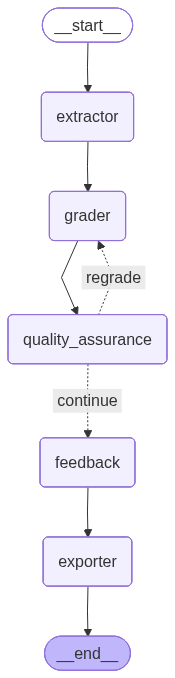

In [2]:
graph = build_graph(
        model="gpt-5",
        temperature=0.0,
    )

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
final_state = graph.invoke(
	input=InputState({
		"student_id": "student_02",
		"dpi": 300,
		"max_pages": 10,
		"exam_file": "Exam Java alternative 2025.txt",
		"rubric_file": "java_criteria.txt",
	}),
	context=Context(),
    )

Extracting answers...
Extracted answers from 10 pages.
Extraction completed.

Grading exam...
Grading completed.

Performing quality assurance on grading results...
Quality assurance completed.

QA cleared. Proceeding to feedback.

Generating feedback for the student...
Feedback generation completed.

Exporting results...
Results exported.



In [4]:
print("\nFinal state:")
final_state.pop("messages")
for k, v in final_state.items():
	print(f"- {k}: {v}")


Final state:
- extract_dir: data\output\student_02\extracted_text
- export_dir: data\output\student_02\grading_results
- log_path: data\output\student_02\messages_log.log
- extractor_result: Student Answers:

Question: 1.1
Answer: means that Java is a Langauge that works with diffirent components architectures

Question: 1.2
Answer: [NO_RESPONSE_PROVIDED]

Question: 1.3
Answer: POP emphisis on the procuders (Code of the data OOP emphysis on the classes & objects [UNK] Cenclusing

Question: 1.4
Answer: JVM , JRE enviroment

Question: 1.5
Answer: inhertance, means creating classes from an existing ones. the inherted class can hasse the methods & filse of the original one- polymorphism:

Question: 1.6
Answer: [NO_RESPONSE_PROVIDED]

Question: 1.7
Answer: = abstract modifiers & interfaces

Question: 1.8
Answer: a- finished its task nermally. b- dead and no longer executes. c- unpredectable events

Question: 1.9
Answer: System.in, system.out, system.err

Question: 1.10
Answer: JDK

Questio

In [5]:
from src.utils import io
import logging

logging.shutdown()

stream = graph.stream(
	input=InputState({
		"student_id": "student_03",
		"dpi": 300,
		"max_pages": 10,
		"exam_file": "Exam Java alternative 2025.txt",
		"rubric_file": "java_criteria.txt",
	}),
	context=Context(),
     stream_mode="updates",
     subgraphs=True,
     version="v2"
        )

for chunk in stream:
     if chunk["ns"]:
          node, values = list(chunk["data"].items())[0]
          print(f"\n- Subgraph[{node}] update\n  Messages:")
          for message in values.get("messages", []):
               message.content = io.truncate_text(message.content, limit=20)
               message.pretty_print()
     else:
          print(f"\n* Root[{list(chunk['data'].keys())[0]}] update\n" + "-" * 100)

Extracting answers...
Extracted answers from
- Subgraph[model] update
  Messages:
================================== Ai Message ==================================

{"exam_structure":[{"question_id":"1.1","student_answer":"means java language is not ties on speciffe oprer operating system architecture"},{"question_id":"1.2","student_answer":"as the w.w.w occur sharing dato become more wide and orgnize at the data previosly stored all in and can be accessed by any code, [UNK] a must togather to devel the end. become a must do develop language that optimized [UNK] data data to it's function and ocode and constraints it's access."},{"question_id":"1.3","student_answer":"OOP (object oriented program) emphasis on data rathe than function eit encapsulate code and data inside class to protect it from misuse. pop (sprecedural orinted program) use data to achieve the aim of function emphasis on function (procedure) rather than data) C is example for this. oop code data code data class java is ex